In [1]:
from tensorflow.keras.datasets import cifar10
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout, BatchNormalization

from tensorflow.keras import losses, optimizers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
print(x_train.shape, y_train.shape)
print(x_test.shape, y_test.shape)

(50000, 32, 32, 3) (50000, 1)
(10000, 32, 32, 3) (10000, 1)


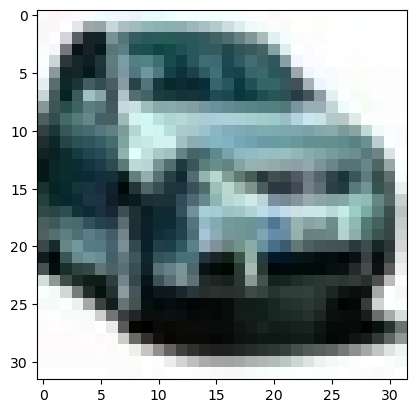

In [3]:
plt.imshow(x_train[23213])

In [4]:
x_train = x_train/255
x_test = x_test/255

In [5]:
y_cat_train = to_categorical(y_train, 10)
y_cat_test = to_categorical(y_test, 10)

print(f'{y_cat_test} ==> {y_train}')

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]] ==> [[6]
 [9]
 [9]
 ...
 [9]
 [1]
 [1]]


In [6]:
model = Sequential([
    Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.20),

    Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.20),

    Conv2D(filters=128, kernel_size=(3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.20),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.20),
    Dense(10, activation='softmax')
])


In [7]:
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [8]:
early_stop = EarlyStopping(monitor='val_loss', restore_best_weights=True, patience=5)

In [9]:
model.fit(x_train, y_cat_train, epochs=10, validation_data=(x_test, y_cat_test),
         callbacks=[early_stop],)

Epoch 1/10
1563/1563 [==============================] - 44s 16ms/step - loss: 1.5197 - accuracy: 0.4593 - val_loss: 1.2979 - val_accuracy: 0.5266
Epoch 2/10
1563/1563 [==============================] - 25s 16ms/step - loss: 1.1753 - accuracy: 0.5852 - val_loss: 1.3038 - val_accuracy: 0.5563
Epoch 3/10
1563/1563 [==============================] - 23s 15ms/step - loss: 1.0398 - accuracy: 0.6344 - val_loss: 1.1846 - val_accuracy: 0.5973
Epoch 4/10
1563/1563 [==============================] - 23s 15ms/step - loss: 0.9566 - accuracy: 0.6630 - val_loss: 0.9875 - val_accuracy: 0.6575
Epoch 5/10
1563/1563 [==============================] - 25s 16ms/step - loss: 0.8876 - accuracy: 0.6900 - val_loss: 0.8575 - val_accuracy: 0.7022
Epoch 6/10
1563/1563 [==============================] - 24s 15ms/step - loss: 0.8421 - accuracy: 0.7050 - val_loss: 0.8271 - val_accuracy: 0.7127
Epoch 7/10
1563/1563 [==============================] - 23s 15ms/step - loss: 0.8003 - accuracy: 0.7215 - val_loss: 0.8406 -

In [10]:
metrics = pd.DataFrame(model.history.history)
metrics

,loss,accuracy,val_loss,val_accuracy
0,1.519684,0.45932,1.297868,0.5266
1,1.175280,0.58518,1.303791,0.5563
2,1.039780,0.63436,1.184624,0.5973
3,0.956645,0.66298,0.987502,0.6575
4,0.887575,0.68998,0.857533,0.7022
5,0.842142,0.70502,0.827126,0.7127
6,0.800262,0.72154,0.840634,0.7148
7,0.773532,0.72924,0.772031,0.7380
8,0.746370,0.73814,0.888825,0.6967
9,0.723430,0.74908,1.076649,0.6555


In [11]:
from sklearn.metrics import classification_report, confusion_matrix

In [12]:
predictions = model.predict(x_test)

313/313 [==============================] - 3s 6ms/step


In [13]:
predictions = np.argmax(predictions, axis=1)

In [14]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

           0       0.88      0.59      0.71      1000
           1       0.94      0.70      0.80      1000
           2       0.62      0.49      0.55      1000
           3       0.50      0.44      0.47      1000
           4       0.58      0.64      0.61      1000
           5       0.66      0.55      0.60      1000
           6       0.41      0.96      0.58      1000
           7       0.80      0.70      0.75      1000
           8       0.81      0.78      0.80      1000
           9       0.85      0.70      0.77      1000

    accuracy                           0.66     10000
   macro avg       0.71      0.66      0.66     10000
weighted avg       0.71      0.66      0.66     10000



<Axes: >

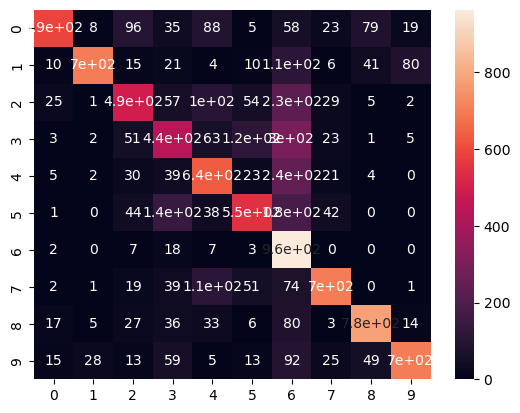

In [15]:
sns.heatmap(confusion_matrix(y_test, predictions), annot=True)

In [16]:
my_image = x_test[1634]

In [17]:
y_test[1634]

array([6], dtype=uint8)

In [18]:
my_reshape_image = my_image.reshape(1, 32, 32, 3)

In [19]:
np.argmax(model.predict(my_reshape_image))

1/1 [==============================] - 0s 382ms/step


6

1/1 [==============================] - 0s 41ms/step
Predicted Class: 6


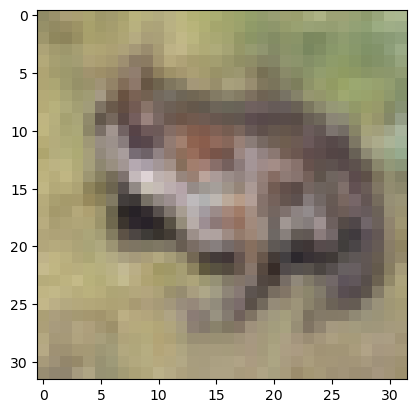

In [20]:
plt.imshow(my_image)
print(f"Predicted Class: {np.argmax(model.predict(my_image.reshape(1, 32, 32, 3)))}")
plt.show()